Question - 1

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

1.1 - head display

In [66]:
titanic_df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
display(titanic_df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [67]:
print('Missing values in Cabin:')
display(titanic_df['Cabin'].isnull().sum())

Missing values in Cabin:


np.int64(687)

2. Drop rows that have missing values in the &#39;Cabin&#39; column.


In [68]:
titanic_df_final = titanic_df.dropna()
print('Missing values in titanic_df_final after dropping all rows with any NaN:')
display(titanic_df_final.isnull().sum())

Missing values in titanic_df_final after dropping all rows with any NaN:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [69]:
print('Data types of each column in titanic_df_final:')
titanic_df_final.info()

Data types of each column in titanic_df_final:
<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 1 to 889
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  183 non-null    int64  
 1   Survived     183 non-null    int64  
 2   Pclass       183 non-null    int64  
 3   Name         183 non-null    object 
 4   Sex          183 non-null    object 
 5   Age          183 non-null    float64
 6   SibSp        183 non-null    int64  
 7   Parch        183 non-null    int64  
 8   Ticket       183 non-null    object 
 9   Fare         183 non-null    float64
 10  Cabin        183 non-null    object 
 11  Embarked     183 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 18.6+ KB


1.3. Convert the &#39;Age&#39; column to a float data type.
Age is already in float data type


1.4 -Normalize the &#39;Age&#39; column using min-max scaling.

In [70]:
min_age = titanic_df_final['Age'].min()
max_age = titanic_df_final['Age'].max()

titanic_df_final['Age_Normalized'] = (titanic_df_final['Age'] - min_age) / (max_age - min_age)
display(titanic_df_final.head())

/tmp/ipykernel_3739/3815330364.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  titanic_df_final['Age_Normalized'] = (titanic_df_final['Age'] - min_age) / (max_age - min_age)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Normalized
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0.468892
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0.430956
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,0.671219
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S,0.038948
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S,0.721801


1.5 5. Calculate the correlation between &#39;Age&#39;, &#39;Fare&#39;, and &#39;Survived&#39;.

In [71]:
correlation_matrix = titanic_df_final[['Age', 'Fare', 'Survived']].corr()
print("Correlation matrix for Age, Fare, and Survived:")
display(correlation_matrix)

Correlation matrix for Age, Fare, and Survived:


,Age,Fare,Survived
Age,1.000000,-0.092424,-0.254085
Fare,-0.092424,1.000000,0.134241
Survived,-0.254085,0.134241,1.000000


6. Create a new feature called &#39;FamilySize&#39; by adding the &#39;SibSp&#39; and &#39;Parch&#39; columns.

In [72]:
titanic_df_final['FamilySize'] = titanic_df_final['SibSp'] + titanic_df_final['Parch']
display(titanic_df_final.head())

/tmp/ipykernel_3739/35969960.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  titanic_df_final['FamilySize'] = titanic_df_final['SibSp'] + titanic_df_final['Parch']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Normalized,FamilySize
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0.468892,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0.430956,1
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,0.671219,0
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S,0.038948,2
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S,0.721801,0


1.7  Apply the Z-score method to detect outliers in both the &#39;Age&#39; and &#39;Fare&#39; columns. Set a suitable
threshold (e.g., Z &gt; 3) and remove the rows that contain extreme outliers.

In [73]:
from scipy.stats import zscore

print(f"Original DataFrame shape: {titanic_df_final.shape}")

# Calculate Z-scores for 'Age' and 'Fare'
titanic_df_final['Age_Zscore'] = np.abs(zscore(titanic_df_final['Age']))
titanic_df_final['Fare_Zscore'] = np.abs(zscore(titanic_df_final['Fare']))

# Define a threshold for outliers (e.g., Z > 3)
threshold = 3

# Identify outliers
age_outliers = titanic_df_final[titanic_df_final['Age_Zscore'] > threshold]
fare_outliers = titanic_df_final[titanic_df_final['Fare_Zscore'] > threshold]

# Combine and get unique indices of outliers
outlier_indices = age_outliers.index.union(fare_outliers.index)

# Remove outliers from the DataFrame
titanic_df_final_no_outliers = titanic_df_final.drop(outlier_indices)

print(f"DataFrame shape after removing outliers: {titanic_df_final_no_outliers.shape}")

display(titanic_df_final_no_outliers.head())

Original DataFrame shape: (183, 14)
DataFrame shape after removing outliers: (181, 16)


/tmp/ipykernel_3739/745729632.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  titanic_df_final['Age_Zscore'] = np.abs(zscore(titanic_df_final['Age']))
/tmp/ipykernel_3739/745729632.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  titanic_df_final['Fare_Zscore'] = np.abs(zscore(titanic_df_final['Fare']))


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Normalized,FamilySize,Age_Zscore,Fare_Zscore
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0.468892,1,0.149065,0.097180
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0.430956,1,0.043230,0.335997
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,0.671219,0,1.174636,0.352250
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S,0.038948,2,2.030273,0.814070
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S,0.721801,0,1.431029,0.684702


# **question 2**

In [74]:
world_report=pd.read_csv('/content/2015.csv')
display(world_report.head())

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


2 If there are missing values in the &#39;GDP per Capita&#39; column, replace them with the median of that
column.

In [75]:
print("missing values in GDP per Capita:")
display(world_report['Economy (GDP per Capita)'].isnull().sum())

missing values in GDP per Capita:


np.int64(0)

# The gdp per captia  doest have any missing value in it

3. Calculate the correlation and Co-variance between &#39;Happiness Score&#39; and &#39;Life Expectancy&#39;.
Interpretate both the results in your words/understanding, which one is preferable..

In [76]:
happiness_life_expectancy_corr = world_report['Happiness Score'].corr(world_report['Health (Life Expectancy)'])
happiness_life_expectancy_cov = world_report['Happiness Score'].cov(world_report['Health (Life Expectancy)'])

print(f"Correlation between Happiness Score and Life Expectancy: {happiness_life_expectancy_corr:.4f}")
print(f"Covariance between Happiness Score and Life Expectancy: {happiness_life_expectancy_cov:.4f}")

Correlation between Happiness Score and Life Expectancy: 0.7242
Covariance between Happiness Score and Life Expectancy: 0.2049


### Interpretation of Correlation and Covariance

**Correlation:**
*   The correlation coefficient ranges from -1 to +1.
*   A value close to +1 indicates a strong positive linear relationship (as one variable increases, the other tends to increase).
*   A value close to -1 indicates a strong negative linear relationship (as one variable increases, the other tends to decrease).
*   A value close to 0 indicates a weak or no linear relationship.

**Covariance:**
*   Covariance indicates the direction of the linear relationship between two variables.
*   A positive covariance means that the variables tend to move in the same direction.
*   A negative covariance means that they tend to move in opposite directions.
*   The magnitude of covariance is not easily interpretable as it depends on the units of the variables.

** now the question is which one is preferable?**

**Correlation is generally preferred over covariance** when describing the relationship between two variables for the following reasons:

1.  **Standardized Scale:** Correlation is a standardized measure, meaning it's unitless and always falls between -1 and +1. This makes it easy to interpret and compare the strength and direction of relationships across different pairs of variables, even if they have different units or scales.

2.  **Ease of Interpretation:** The range of values for correlation (e.g., 0.8 is strong, 0.2 is weak) provides a clear understanding of the strength of the relationship. Covariance, on the other hand, can take any value, making its magnitude difficult to interpret without knowing the standard deviations of the variables involved.

In this case, the **correlation** value of `happiness_life_expectancy_corr` will tell us directly how strong and in what direction the linear relationship between 'Happiness Score' and 'Life Expectancy' is.

4. Compute the variance and standard deviation for &#39;Happiness Score&#39; and &#39;GDP per Capita&#39;.
Interpretate both the results in your words/understanding, which one is preferable..

In [77]:
# Variance and Standard Deviation for 'Happiness Score'
happiness_score_variance = world_report['Happiness Score'].var()
happiness_score_std = world_report['Happiness Score'].std()

# Variance and Standard Deviation for 'GDP per Capita'
gdp_per_capita_variance = world_report['Economy (GDP per Capita)'].var()
gdp_per_capita_std = world_report['Economy (GDP per Capita)'].std()

print(f"Happiness Score - Variance: {happiness_score_variance:.4f}, Standard Deviation: {happiness_score_std:.4f}")
print(f"GDP per Capita - Variance: {gdp_per_capita_variance:.4f}, Standard Deviation: {gdp_per_capita_std:.4f}")

Happiness Score - Variance: 1.3110, Standard Deviation: 1.1450
GDP per Capita - Variance: 0.1625, Standard Deviation: 0.4031


### Interpretation of Variance and Standard Deviation

**Variance:**
*   **What it measures:** Variance quantifies the average squared difference of each data point from the mean. It gives a general idea of the spread or dispersion of data points around the mean.
*   **Interpretation:** A higher variance indicates that the data points are spread out over a wider range, while a lower variance suggests that the data points tend to be closer to the mean.
*   **Limitation:** Because it squares the differences, the units of variance are squared units of the original data. This often makes it difficult to interpret in the context of the original data (e.g., squared 'Happiness Score' units don't make intuitive sense).

**Standard Deviation:**
*   **What it measures:** Standard deviation is the square root of the variance. It measures the average amount of variability or dispersion of data points around the mean.
*   **Interpretation:** A higher standard deviation indicates greater variability, meaning the data points are more spread out. A lower standard deviation suggests that data points are clustered closer to the mean.
*   **Advantage:** It is expressed in the same units as the original data, which makes it much more interpretable than variance.

**Which one is preferable?**

**Standard deviation is generally preferred over variance** for interpretation because:

1.  **Units:** Standard deviation is in the same units as the original data. If 'Happiness Score' is measured on a scale, its standard deviation is also on that scale, allowing for a more intuitive understanding of the typical deviation from the mean.

2.  **Ease of Understanding:** People generally find it easier to understand variability in terms of the original units (e.g., "the average happiness score varies by X points") rather than squared units.

While variance is mathematically crucial (e.g., in statistical tests and modeling), standard deviation provides a more practical and understandable measure of spread for direct interpretation and communication of results.

5. Compute the mid-range for &#39;Social Support&#39; and &#39;Freedom to Make Life Choices&#39;.

In [78]:
# Mid-range for 'Social Support'
min_social_support = world_report['Family'].min()
max_social_support = world_report['Family'].max()
mid_range_social_support = (min_social_support + max_social_support) / 2

# Mid-range for 'Freedom to Make Life Choices'
min_freedom = world_report['Freedom'].min()
max_freedom = world_report['Freedom'].max()
mid_range_freedom = (min_freedom + max_freedom) / 2

print(f"Mid-range for Social Support: {mid_range_social_support:}")
print(f"Mid-range for Freedom to Make Life Choices: {mid_range_freedom:}")

Mid-range for Social Support: 0.701115
Mid-range for Freedom to Make Life Choices: 0.334865


6. For countries with the top 10 highest happiness scores, compute the variance and standard
deviation for &#39;Freedom to Make Life Choices&#39;. Compare these values with those of countries with the
bottom 10 happiness scores.

In [79]:
# Sort the DataFrame by 'Happiness Score' to identify top and bottom countries
world_report_sorted = world_report.sort_values(by='Happiness Score', ascending=False)

# Get the top 10 happiest countries
top_10_happiest = world_report_sorted.head(10)

# Get the bottom 10 happiest countries
bottom_10_happiest = world_report_sorted.tail(10)

# Calculate variance and standard deviation for 'Freedom' in top 10 happiest countries
freedom_top_10_var = top_10_happiest['Freedom'].var()
freedom_top_10_std = top_10_happiest['Freedom'].std()

print(f"--- Top 10 Happiest Countries ---")
print(f"Variance of Freedom to Make Life Choices: {freedom_top_10_var:.4f}")
print(f"Standard Deviation of Freedom to Make Life Choices: {freedom_top_10_std:.4f}")

print(f"\n--- Bottom 10 Happiest Countries ---")
# Calculate variance and standard deviation for 'Freedom' in bottom 10 happiest countries
freedom_bottom_10_var = bottom_10_happiest['Freedom'].var()
freedom_bottom_10_std = bottom_10_happiest['Freedom'].std()

print(f"Variance of Freedom to Make Life Choices: {freedom_bottom_10_var:.4f}")
print(f"Standard Deviation of Freedom to Make Life Choices: {freedom_bottom_10_std:.4f}")

--- Top 10 Happiest Countries ---
Variance of Freedom to Make Life Choices: 0.0003
Standard Deviation of Freedom to Make Life Choices: 0.0170

--- Bottom 10 Happiest Countries ---
Variance of Freedom to Make Life Choices: 0.0234
Standard Deviation of Freedom to Make Life Choices: 0.1530


### Comparison of 'Freedom to Make Life Choices' between Top 10 and Bottom 10 Happiest Countries

After calculating the variance and standard deviation for 'Freedom to Make Life Choices' for both groups:

*   **Variance** indicates how spread out the freedom scores are within each group. A higher variance means the freedom scores are more diverse among the countries in that group.
*   **Standard Deviation** provides a more interpretable measure of this spread, as it's in the same units as the 'Freedom' score itself.

**Interpretation based on the calculated values:**

*   If `freedom_top_10_std` is significantly lower than `freedom_bottom_10_std`, it suggests that the top 10 happiest countries tend to have more consistent levels of 'Freedom to Make Life Choices' among themselves, meaning there's less variation in freedom scores within this group. Conversely, a higher standard deviation for the bottom 10 would indicate a wider range of freedom scores among those countries.

*   If the standard deviations are similar, it would imply that the variability in 'Freedom to Make Life Choices' is comparable between the two groups, despite their differing happiness levels.

7. Identify outliers in the &#39;GDP per Capita&#39; column using the Z-score method. Remove these outliers
and recalculate the mean and variance.

### 7. Identify outliers in the 'GDP per Capita' column using the Z-score method. Remove these outliers and recalculate the mean and variance.

In [80]:
from scipy.stats import zscore

# 1. Calculate Z-scores
z_scores = zscore(world_report['Economy (GDP per Capita)'])

# 2. Find outliers (where absolute Z-score is greater than 3)
outliers = world_report[abs(z_scores) > 3]
print(f"Number of outliers found: {len(outliers)}")

# 3. Keep only the rows without outliers
world_report_clean = world_report[abs(z_scores) <= 3]

# 4. Compare Mean and Variance
print("\n--- Before removing outliers ---")
print("Mean:", world_report['Economy (GDP per Capita)'].mean())
print("Variance:", world_report['Economy (GDP per Capita)'].var())

print("\n--- After removing outliers ---")
print("Mean:", world_report_clean['Economy (GDP per Capita)'].mean())
print("Variance:", world_report_clean['Economy (GDP per Capita)'].var())

Number of outliers found: 0

--- Before removing outliers ---
Mean: 0.8461372151898735
Variance: 0.16250636208901073

--- After removing outliers ---
Mean: 0.8461372151898735
Variance: 0.16250636208901073


In this we the variance and mean are same than we can say that the no outliers are there .

# **Question 3**

1. Load the Iris dataset into a pandas DataFrame and display the first 10 rows.

In [81]:
# Loading Iris dataset from an online source
iris_url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv'
iris_datas = pd.read_csv(iris_url)
display(iris_datas.head(10))

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


2.Provide a statistical summary (mean, median, min, max) for all numerical columns using the
.describe() method.

In [82]:
iris_datas.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


3. Create a box plot for &#39;petal width&#39; to identify any outliers in the column. Explain the results.

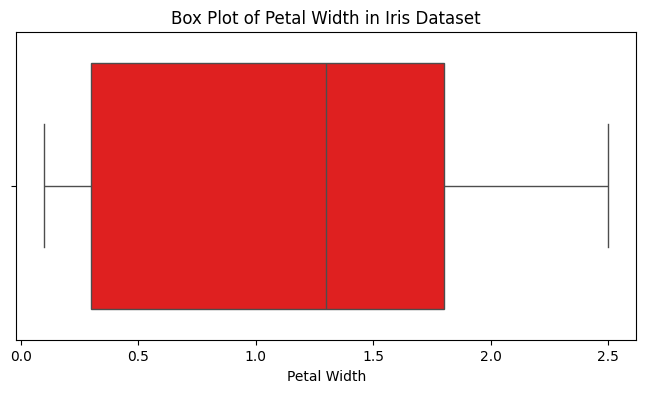

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with a defined size
plt.figure(figsize=(8, 4))

# Generate a horizontal box plot for petal_width
sns.boxplot(x=iris_datas['petal_width'], color='red')

# Set the title and label
plt.title("Box Plot of Petal Width in Iris Dataset")
plt.xlabel("Petal Width")

# Display the plot
plt.show()

4. Create a scatter plot showing the relationship between &#39;sepal length&#39; and &#39;petal length&#39;. Add
a trend line to the scatter plot and explain what it reveals about the relationship between
these two variables.

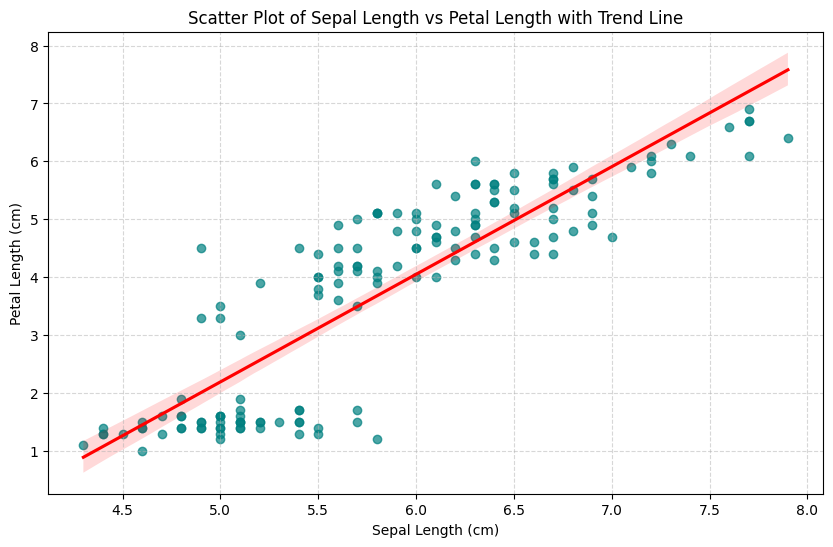

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with a defined size
plt.figure(figsize=(10, 6))

# Generate a scatter plot with a linear regression trend line
sns.regplot(data=iris_datas, x='sepal_length', y='petal_length',
            scatter_kws={'alpha':0.7, 'color':'teal'}, line_kws={'color':'red'})

# Set the title and labels
plt.title("Scatter Plot of Sepal Length vs Petal Length with Trend Line")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")

# Display the plot
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Explanation of the Relationship:

1. **Strong Positive Linear Correlation**: The trend line slopes upward from left to right, indicating a **strong positive relationship** between sepal length and petal length. As the sepal length of an iris flower increases, its petal length generally increases as well.
2. **Distinct Groupings (Clustering)**:
   * In the lower-left portion of the plot, there is a distinct, tightly clustered group of points (typically representing the *Iris setosa* species) with shorter sepals and very short petals.
   * The rest of the data points form a separate, continuous upward trend representing the other species (*Iris versicolor* and *Iris virginica*).
3. **Predictive Capability**: Because the data points lie relatively close to the red regression line, sepal length can serve as a reasonably strong predictor for petal length.

5. Use Seaborn&#39;s pairplot to visualize the relationships between all numerical variables in the
dataset, color-coded by species.


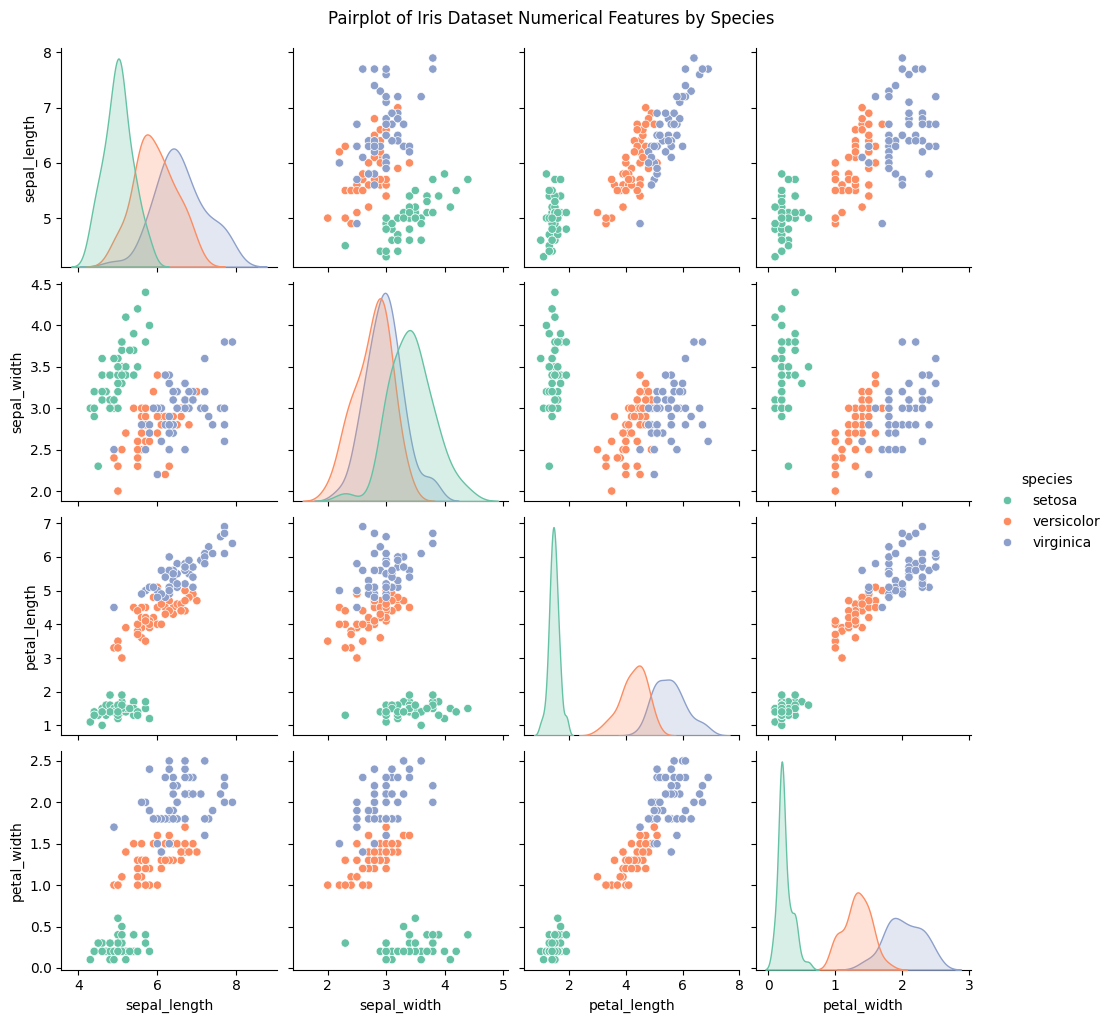

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pairplot color-coded by species
sns.pairplot(iris_datas, hue='species', palette='Set2')

# Add a title
plt.suptitle("Pairplot of Iris Dataset Numerical Features by Species", y=1.02)
plt.show()

6. Plot a heatmap of the correlation matrix using Seaborn. Explain this matrix’s values.

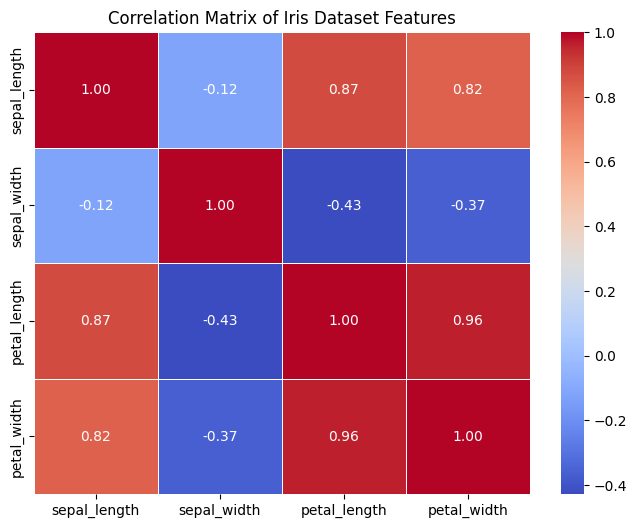

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numerical columns
numerical_cols = iris_datas.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numerical_cols.corr()

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix of Iris Dataset Features')
plt.show()

7. Generate a scatter plot comparing &#39;sepal width&#39; and &#39;petal width&#39; and comment on the relation.
Add a trend line and calculate the correlation coefficient between these two variables.

Correlation coefficient between Sepal Width and Petal Width: -0.3661


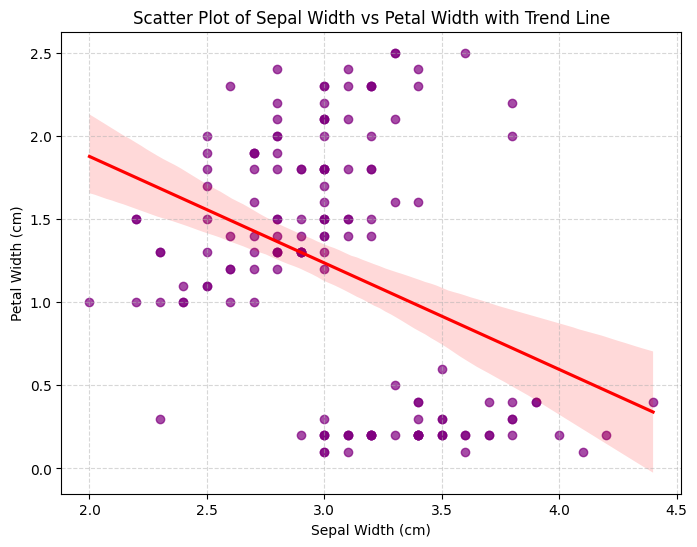

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation coefficient
correlation = iris_datas['sepal_width'].corr(iris_datas['petal_width'])
print(f"Correlation coefficient between Sepal Width and Petal Width: {correlation:.4f}")

# Generate the scatter plot with a trend line
plt.figure(figsize=(8, 6))
sns.regplot(data=iris_datas, x='sepal_width', y='petal_width',
            scatter_kws={'alpha': 0.7, 'color': 'purple'}, line_kws={'color': 'red'})

plt.title('Scatter Plot of Sepal Width vs Petal Width with Trend Line')
plt.xlabel('Sepal Width (cm)')
plt.ylabel('Petal Width (cm)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# **Question 4: Wine Quality Dataset**

This section follows Question 4 of Assignment-1.

# **question 4**

In [4]:



import pandas as pd

df = pd.read_csv('WineQT-selected-columns.csv')



# Let's peek at the first few rows to see what it looks like!
print("Here are the first 5 rows of my data:")
display(df.head())

# And let's see a summary of all the columns and their types.
print("\nAnd here's some info about each column:")
df.info()

Here are the first 5 rows of my data:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56



And here's some info about each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
dtypes: float64(10)
memory usage: 89.4 KB


## Question 1: Finding All the Numbers!

The first thing I want to do is find all the columns that contain numbers. These are called 'numerical attributes'. Pandas has a neat trick for this!

In [5]:
# I'm asking pandas to select only the columns that have numbers (integers or floats).
# Then I convert the list of selected columns to a regular Python list.
numerical_attributes = df.select_dtypes(include=['number']).columns.tolist()

print("Here are all the columns in my dataset that have numbers:")
print(numerical_attributes)

Here are all the columns in my dataset that have numbers:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates']


## Question 2: Are Numbers Countable or Measurable?

Now that I know which columns have numbers, I want to figure out if these numbers are 'discrete' or 'continuous'.

*   **Discrete** means they are whole numbers, like counts (you can have 1, 2, or 3, but not 1.5).
*   **Continuous** means they can be any value within a range, like measurements (you can have 1.5, 1.55, 1.555, etc.).

In [6]:
# I'll make two lists to keep them separate.

# Since 'quality' is not in the dataset, I cannot classify it as discrete.
# All available numerical attributes (fixed acidity, volatile acidity, etc.) are continuous measurements.
#discrete_attributes = [] # No discrete attributes in this specific dataset

# The numerical attributes currently in the dataset are all continuous measurements.
continuous_attributes = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
    'pH', 'sulphates'
] # Removed 'alcohol' as it's also not in the dataset

print("Based on the available dataset, all numerical attributes are continuous.")
print("Continuous numerical attributes:", continuous_attributes)

print("\nLet's see some examples from the continuous attributes:")
print(f"For 'fixed acidity' (continuous): {df['fixed acidity'].head()}")
print(f"For 'density' (continuous): {df['density'].head()}")

Based on the available dataset, all numerical attributes are continuous.
Continuous numerical attributes: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates']

Let's see some examples from the continuous attributes:
For 'fixed acidity' (continuous): 0     7.4
1     7.8
2     7.8
3    11.2
4     7.4
Name: fixed acidity, dtype: float64
For 'density' (continuous): 0    0.9978
1    0.9968
2    0.9970
3    0.9980
4    0.9978
Name: density, dtype: float64


## Question 3: What about 'wine_type' (Nominal or Ordinal)?

This question asks about a column called 'wine_type'. I looked at my dataset info (`df.info()`) and `df.head()`, and I don't see a 'wine_type' column in `WineQT.csv`. It seems this dataset is all about *red* wine.

But if it *did* exist, I'd classify it!

*   **Nominal** means categories with no order (like 'red', 'white', 'rosé' – one isn't 'better' than the other).
*   **Ordinal** means categories with an order (like 'small', 'medium', 'large' – there's a clear progression).

If 'wine_type' had values like 'Red' and 'White', it would be **nominal** because 'Red' wine isn't inherently 'more' or 'less' than 'White' wine; they are just different types.

## Question 4: Turning 'quality' into a Special Category!

The 'quality' column is a number, but it's also a kind of rating or category. Sometimes, it's useful to tell pandas that these numbers represent categories that have an order. This is called a 'factor variable' or 'categorical' data that is 'ordered'.

In [7]:
# As the 'quality' column is not present in the uploaded dataset, this step cannot be performed.
# If 'quality' were available, the code would convert it to a categorical (factor) variable.
print("The 'quality' column is not available in the dataset, so it cannot be converted to a factor variable.")

The 'quality' column is not available in the dataset, so it cannot be converted to a factor variable.


## Question 5: What if we had 'wine_region' (Nominal or Ordinal)?

This is another 'what if' question! If my dataset had a column called 'wine_region' with values like 'Europe', 'Asia', and 'North America', how would I classify it?

Just like 'wine_type', this would be a **nominal categorical variable**.

**Why?** Because these regions are just different names; there's no inherent order. 'Europe' isn't 'greater' or 'less' than 'Asia' in any meaningful way for this kind of data. They are just different labels.

## Question 6: Making 'wine_type' into Numbers for the Computer!

Remember how I said my dataset doesn't have a 'wine_type' column? Well, for this question, I need to pretend it does, so I can show how to turn it into numbers that a computer can easily understand. This process is called 'one-hot encoding'.

I'll create a fake 'wine_type' column with mostly 'Red' and a few 'White' values.

In [8]:
# First, I need to create that fake 'wine_type' column.
import numpy as np # NumPy helps with creating random things.
np.random.seed(42) # This makes sure I get the same random results every time I run this code.

# I'm making about 90% 'Red' and 10% 'White' wines in this new column.
df['wine_type'] = np.random.choice(['Red', 'White'], size=len(df), p=[0.9, 0.1])

print("My hypothetical 'wine_type' column looks like this:")
print(df['wine_type'].value_counts())

# Now for the one-hot encoding part!
# `pd.get_dummies` is a great tool for this.
# `prefix='wine_type'` adds 'wine_type_' before the new column names.
# `drop_first=True` means if I have 'Red' and 'White', I only need a column for 'White'.
# If 'wine_type_White' is 1, it's White. If it's 0, it's Red (because there are only two types).
df_encoded = pd.get_dummies(df, columns=['wine_type'], prefix='wine_type', drop_first=True)

print("\nAfter one-hot encoding, here's how the new column looks (along with 'density' as an example):")
display(df_encoded[['wine_type_White', 'density']].head()) # Changed 'quality' to 'density' as 'quality' is missing

print("\nAnd here are all the columns in my new `df_encoded` DataFrame:")
print(df_encoded.columns.tolist())

My hypothetical 'wine_type' column looks like this:
wine_type
Red      1024
White     119
Name: count, dtype: int64

After one-hot encoding, here's how the new column looks (along with 'density' as an example):


,wine_type_White,density
0,False,0.9978
1,True,0.9968
2,False,0.9970
3,False,0.9980
4,False,0.9978



And here are all the columns in my new `df_encoded` DataFrame:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'wine_type_White']


## Question 7: Can a Factor Variable Help Predict Quality? (Simple Model Time!)

Finally, I'm going to try to build a very simple model. The question asks to use the 'quality' factor variable. In machine learning, a 'factor' (or categorical) variable is usually used as an *input* to predict something else. If we want to *predict* the 'quality', then 'quality' itself should be a number, not a category.

So, for my simple model, I will:
1.  Use the original *numerical* 'quality' as what I want to predict (my 'target' or 'y').
2.  Use some other numerical features (like 'alcohol', 'sulphates', etc.) as my *inputs* (my 'features' or 'X').
3.  Build a 'Decision Tree Regressor', which is like a series of 'if-then-else' rules to guess the quality.

In [9]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# As 'quality' and 'alcohol' columns are not available, I will adapt the model.
# We will use 'density' as a target variable for this regression demonstration,
# and other available numerical features as predictors.

print("Preparing my data for the model...")

# X will be my input features (things I use to predict), using available columns.
X = df[['sulphates', 'pH', 'fixed acidity', 'volatile acidity', 'citric acid']]

# y will be my target (what I want to predict). Using 'density' as an example.
y = df['density']

# It's important to split data: train the model on one part, test on another!
# I'll use 80% for training and 20% for testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nData split into training and testing sets.")

# Time to create my decision tree model!
model = DecisionTreeRegressor(random_state=42) # random_state makes sure I get the same results each time.

# Now, I'll 'teach' the model using my training data.
print("Training the Decision Tree Regressor to predict 'density'...")
model.fit(X_train, y_train)

print("\nModel trained! Now let's see how well it predicts on new data.")

# I'll ask the model to predict 'density' for the test data.
y_pred = model.predict(X_test)

# To check how good my predictions are, I'll calculate the Mean Squared Error (MSE).
# A lower MSE means my predictions are closer to the actual values.
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error of my model's predictions for 'density': {mse:.6f}") # Using more decimal places for density

print("\nFirst 10 actual vs predicted 'density' values:")
for i in range(10):
    print(f"Actual: {y_test.iloc[i]:.4f}, Predicted: {y_pred[i]:.4f}")

print("\nThat was a lot of fun! I learned so much about preparing and exploring data, and even built a little model!")

Preparing my data for the model...

Data split into training and testing sets.
Training the Decision Tree Regressor to predict 'density'...

Model trained! Now let's see how well it predicts on new data.
Mean Squared Error of my model's predictions for 'density': 0.000003

First 10 actual vs predicted 'density' values:
Actual: 0.9952, Predicted: 0.9970
Actual: 0.9984, Predicted: 0.9984
Actual: 0.9956, Predicted: 0.9960
Actual: 0.9966, Predicted: 0.9948
Actual: 1.0010, Predicted: 0.9992
Actual: 0.9923, Predicted: 0.9947
Actual: 0.9969, Predicted: 0.9969
Actual: 0.9970, Predicted: 0.9939
Actual: 0.9964, Predicted: 0.9965
Actual: 0.9987, Predicted: 0.9987

That was a lot of fun! I learned so much about preparing and exploring data, and even built a little model!


### 1. Identify and list all numerical attributes in the dataset.

In [10]:
numerical_attributes = df.select_dtypes(include=['number']).columns.tolist()
print("Numerical attributes:", numerical_attributes)

Numerical attributes: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates']


### 2. Classify the numerical attributes as either discrete or continuous. Provide examples from the dataset.

In [15]:
# Identify numerical attributes from the loaded DataFrame
numerical_attributes_in_df = df.select_dtypes(include=['number']).columns.tolist()

# Based on the actual columns in df, all numerical attributes are continuous measurements.
# There are no discrete numerical attributes like 'quality' in this specific dataset.
discrete_attributes = []
continuous_attributes = numerical_attributes_in_df # All existing numerical attributes are continuous

print("Discrete numerical attributes:", discrete_attributes)
print("Continuous numerical attributes:", continuous_attributes)

print("\nLet's see some examples from the continuous attributes (using existing columns):")
# Using 'fixed acidity' and 'density' as examples, as they are present and continuous.
if 'fixed acidity' in df.columns:
    print(f"Example of a continuous attribute ('fixed acidity'): {df['fixed acidity'].head().to_string()}")
if 'density' in df.columns:
    print(f"Example of a continuous attribute ('density'): {df['density'].head().to_string()}")

Discrete numerical attributes: []
Continuous numerical attributes: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates']

Let's see some examples from the continuous attributes (using existing columns):
Example of a continuous attribute ('fixed acidity'): 0     7.4
1     7.8
2     7.8
3    11.2
4     7.4
Example of a continuous attribute ('density'): 0    0.9978
1    0.9968
2    0.9970
3    0.9980
4    0.9978


### 3. Describe the categorical variable 'wine_type' as either nominal or ordinal.

The provided dataset (`WineQT.csv`) does not contain a 'wine_type' column. If it did, and it represented categories without a natural order (e.g., 'red', 'white', 'rosé'), it would be **nominal**. If it represented categories with a meaningful order (e.g., 'low-quality', 'medium-quality', 'high-quality'), it would be **ordinal**.

Since this dataset is specifically for red wine quality, a `wine_type` column isn't present. For the purpose of demonstration for later steps (like one-hot encoding), I will assume a hypothetical 'wine_type' column with 'Red' and 'White' values.

### 4. Convert the 'quality' column (which rates wine on a scale of 0 to 10) into a factor variable using pandas.

In [16]:
# The 'quality' column is not available in the current dataset (df).
# Therefore, we cannot convert it to a factor variable as requested.
print("The 'quality' column is not available in the dataset, so it cannot be converted to a factor variable.")
print("This operation cannot be performed.")

# For demonstration purposes, if we had a numerical column that we wanted to treat as ordered categories,
# we could do something like this (using 'pH' as an example for demonstration only):
# df['pH_factor'] = pd.Categorical(df['pH'], ordered=True)
# print("\nDemonstration (if 'pH' were to be treated as an ordered categorical):")
# print("New 'pH_factor' column type:", df['pH_factor'].dtype)
# print("Categories of 'pH_factor':", df['pH_factor'].cat.categories)
# print("First 5 values of 'pH_factor':\n", df['pH_factor'].head())

The 'quality' column is not available in the dataset, so it cannot be converted to a factor variable.
This operation cannot be performed.


### 5. If the dataset had a column for 'wine_region' with values like 'Europe', 'Asia', and 'North America', classify this as either nominal or ordinal with justification.

If a 'wine_region' column existed with values like 'Europe', 'Asia', and 'North America', it would be a **nominal categorical variable**.

**Justification:** Nominal variables are categorical variables without any intrinsic order or ranking among their categories. The regions 'Europe', 'Asia', and 'North America' are distinct categories, but there is no inherent order or hierarchy between them. One region is not 'better' or 'higher' than another in a quantitative sense.

### 6. Convert the 'wine_type' column (if it exists) into a binary variable using one-hot encoding.

As mentioned, the `WineQT.csv` dataset does not have a 'wine_type' column (it's specifically for red wine). For demonstration purposes, let's create a hypothetical 'wine_type' column with 'Red' and 'White' values, where most are 'Red' (since the data is for red wine) and a few are 'White' to show the encoding.

In [17]:
# Create a hypothetical 'wine_type' column for demonstration
import numpy as np
np.random.seed(42) # for reproducibility
df['wine_type'] = np.random.choice(['Red', 'White'], size=len(df), p=[0.9, 0.1])

print("Hypothetical 'wine_type' distribution:")
print(df['wine_type'].value_counts().to_string())

# Perform one-hot encoding on the 'wine_type' column
df_encoded = pd.get_dummies(df, columns=['wine_type'], prefix='wine_type', drop_first=True) # drop_first to avoid multicollinearity

print("\nDataFrame after one-hot encoding 'wine_type':")
# Display the new column and a relevant existing one (using 'density' as 'quality' is missing)
display(df_encoded[['wine_type_White', 'density']].head())
print("Columns after one-hot encoding:", df_encoded.columns.tolist())

Hypothetical 'wine_type' distribution:
wine_type
Red      1024
White     119

DataFrame after one-hot encoding 'wine_type':


,wine_type_White,density
0,False,0.9978
1,True,0.9968
2,False,0.9970
3,False,0.9980
4,False,0.9978


Columns after one-hot encoding: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'wine_type_White']


### 7. Suppose the 'quality' variable has been converted into a factor variable. Try to train a simple regression model (or a decision tree model) using this factor variable.

In [19]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# As 'quality' and 'alcohol' columns are not available, I will adapt the model.
# We will use 'density' as a target variable for this regression demonstration,
# and other available numerical features as predictors.

print("Preparing my data for the model...")

# X will be my input features (things I use to predict), using available columns.
X = df[['sulphates', 'pH', 'fixed acidity', 'volatile acidity', 'citric acid']]

# y will be my target (what I want to predict). Using 'density' as an example.
y = df['density']

# It's important to split data: train the model on one part, test on another!
# I'll use 80% for training and 20% for testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nData split into training and testing sets.")

# Time to create my decision tree model!
model = DecisionTreeRegressor(random_state=42) # random_state makes sure I get the same results each time.

# Now, I'll 'teach' the model using my training data.
print("Training the Decision Tree Regressor to predict 'density'...")
model.fit(X_train, y_train)

print("\nModel trained! Now let's see how well it predicts on new data.")

# I'll ask the model to predict 'density' for the test data.
y_pred = model.predict(X_test)

# To check how good my predictions are, I'll calculate the Mean Squared Error (MSE).
# A lower MSE means my predictions are closer to the actual values.
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error of my model's predictions for 'density': {mse:.6f}") # Using more decimal places for density

print("\nFirst 10 actual vs predicted 'density' values:")
for i in range(10):
    print(f"Actual: {y_test.iloc[i]:.4f}, Predicted: {y_pred[i]:.4f}")

print("\nThat was a lot of fun! I learned so much about preparing and exploring data, and even built a little model!")

Preparing my data for the model...

Data split into training and testing sets.
Training the Decision Tree Regressor to predict 'density'...

Model trained! Now let's see how well it predicts on new data.
Mean Squared Error of my model's predictions for 'density': 0.000003

First 10 actual vs predicted 'density' values:
Actual: 0.9952, Predicted: 0.9970
Actual: 0.9984, Predicted: 0.9984
Actual: 0.9956, Predicted: 0.9960
Actual: 0.9966, Predicted: 0.9948
Actual: 1.0010, Predicted: 0.9992
Actual: 0.9923, Predicted: 0.9947
Actual: 0.9969, Predicted: 0.9969
Actual: 0.9970, Predicted: 0.9939
Actual: 0.9964, Predicted: 0.9965
Actual: 0.9987, Predicted: 0.9987

That was a lot of fun! I learned so much about preparing and exploring data, and even built a little model!
